# EDA — Système de Recommandation de Films
**Moussa Seye — EPT DIC3 | MLOps**

Dataset : MovieLens ml-latest-small (GroupLens Research)  
**100 836 notes brutes · 610 utilisateurs · 9 742 films · 1902–2018**

Pipeline data : `raw → interim → processed`

## 1. Imports & Configuration

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from loguru import logger

PROJECT_DIR = Path.cwd().parent
sys.path.insert(0, str(PROJECT_DIR))

from settings.params import (
    MLFLOW_TRACKING_URI, EXPERIMENT_NAME,
    DATA_DIR_RAW, DATA_DIR_INTERIM, DATA_DIR_PROCESSED,
    MODEL_PARAMS, SEED, TIMEZONE,
)
from src.data_loader import load_all, load_ratings, load_movies, dataset_summary
from src.features import (
    build_surprise_dataset,
    build_user_item_matrix,
    build_user_features,
    build_item_features,
    encode_genres,
)

log_fmt = "<green>{time:YYYY-MM-DD HH:mm:ss!UTC}</green> | <level>{level: <8}</level> | {message}"
logger.remove()
logger.add(sys.stderr, format=log_fmt, level="INFO")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

print(f"raw/       : {DATA_DIR_RAW}")
print(f"interim/   : {DATA_DIR_INTERIM}")
print(f"processed/ : {DATA_DIR_PROCESSED}")

raw/       : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/raw
interim/   : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/interim
processed/ : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/processed


## 2. Chargement des données (depuis interim)

In [2]:
data    = load_all()
ratings = data["ratings"]
movies  = data["movies"]
tags    = data["tags"]

print(f"ratings : {ratings.shape}")
print(f"movies  : {movies.shape}")
print(f"tags    : {tags.shape}")

2026-06-10 09:36:00 | INFO     | Interim ratings déjà présent : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/interim/ratings_filtered.parquet
2026-06-10 09:36:00 | INFO     | Interim movies déjà présent : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/interim/movies_clean.parquet
2026-06-10 09:36:00 | INFO     | Interim tags déjà présent : /Users/macbookpro/Desktop/DIC3/ML_ops/projet-moussa-seye/data/interim/tags_clean.parquet


ratings : (90274, 4)
movies  : (9742, 6)
tags    : (3683, 4)


In [3]:
ratings.head()

,userid,movieid,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies.head()

,movieid,title,genres,year,title_clean,genres_list
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,Jumanji,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,Waiting to Exhale,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II,[Comedy]


## 3. Métriques descriptives + MLflow

In [5]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

summary = dataset_summary(ratings, movies)

with mlflow.start_run(run_name="EDA_dataset_summary"):
    mlflow.log_metrics({k: v for k, v in summary.items() if isinstance(v, (int, float))})
    logger.success("Métriques EDA loggées dans MLflow")

pd.DataFrame([summary]).T.rename(columns={0: "Valeur"})

2026-06-10 09:36:00 | INFO     | Résumé dataset : {'n_ratings': 90274, 'n_users': 610, 'n_items': 3650, 'density_pct': 4.0545, 'avg_rating': 3.5374, 'std_rating': 1.0299, 'n_genres': 20}
2026-06-10 09:36:00 | SUCCESS  | Métriques EDA loggées dans MLflow


,Valeur
n_ratings,90274.0000
n_users,610.0000
n_items,3650.0000
density_pct,4.0545
avg_rating,3.5374
std_rating,1.0299
n_genres,20.0000


## 4. Distribution des notes

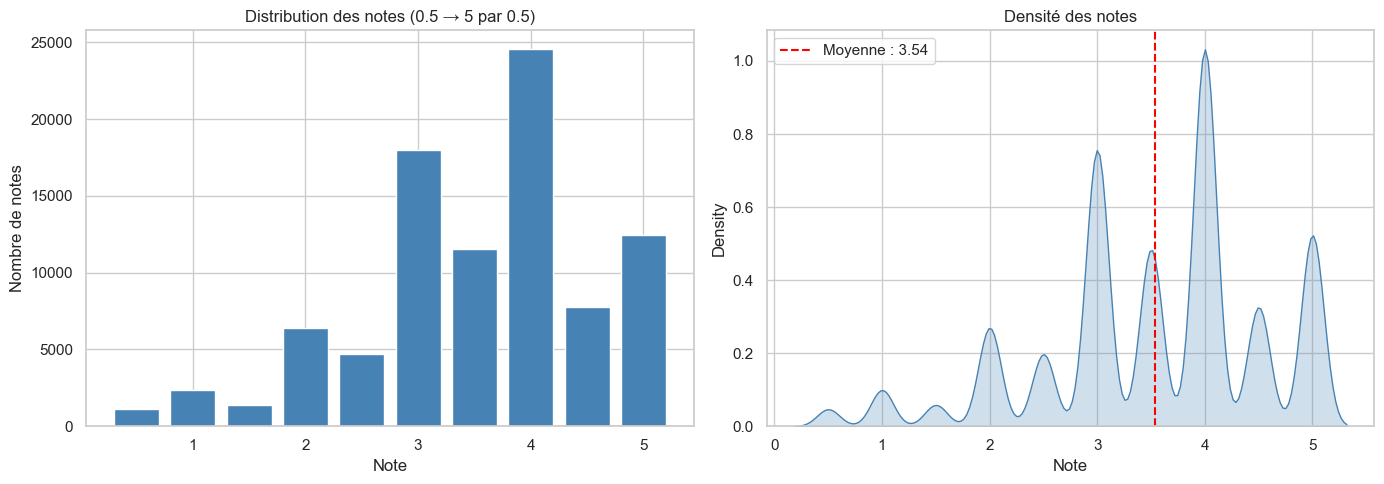

count    90274.000
mean         3.537
std          1.030
min          0.500
25%          3.000
50%          3.500
75%          4.000
max          5.000
Name: rating, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color="steelblue", width=0.4, edgecolor="white")
axes[0].set_title("Distribution des notes (0.5 → 5 par 0.5)")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre de notes")

sns.kdeplot(ratings["rating"], ax=axes[1], fill=True, color="steelblue")
axes[1].axvline(ratings["rating"].mean(), color="red", linestyle="--",
                label=f"Moyenne : {ratings['rating'].mean():.2f}")
axes[1].set_title("Densité des notes")
axes[1].set_xlabel("Note")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "distribution_notes.png", dpi=150, bbox_inches="tight")
plt.show()

print(ratings["rating"].describe().round(3))

## 5. Activité utilisateurs et films

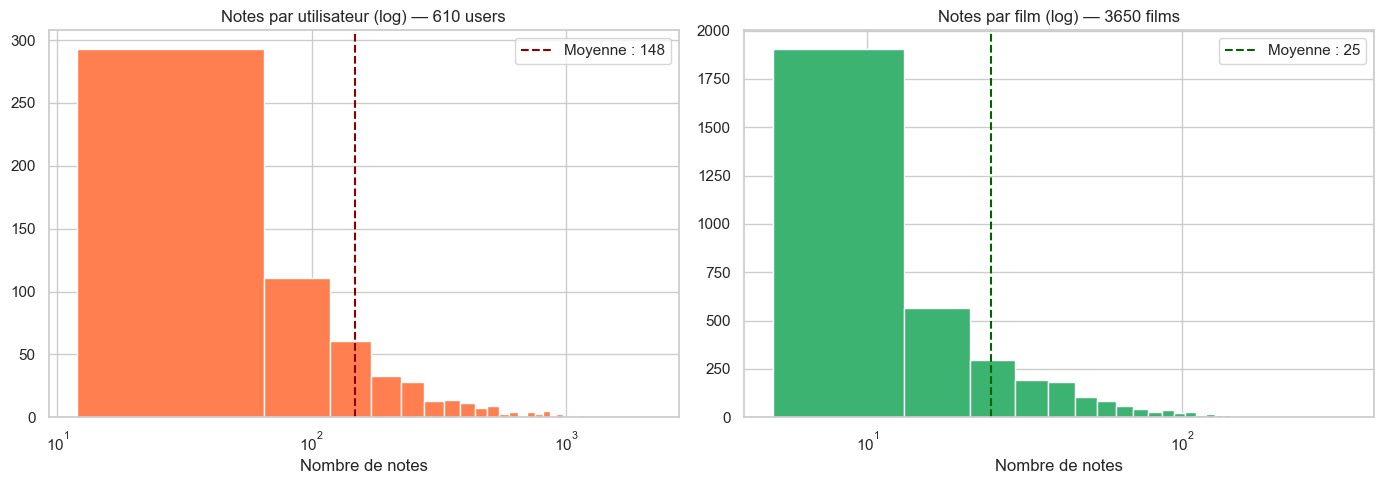

Users  — min:12 max:2132 médiane:68
Films  — min:5 max:329 médiane:13


In [7]:
user_counts = ratings.groupby("userid").size().sort_values(ascending=False)
item_counts = ratings.groupby("movieid").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_counts, bins=40, color="coral", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title(f"Notes par utilisateur (log) — {len(user_counts)} users")
axes[0].set_xlabel("Nombre de notes")
axes[0].axvline(user_counts.mean(), color="darkred", linestyle="--",
                label=f"Moyenne : {user_counts.mean():.0f}")
axes[0].legend()

axes[1].hist(item_counts, bins=40, color="mediumseagreen", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title(f"Notes par film (log) — {len(item_counts)} films")
axes[1].set_xlabel("Nombre de notes")
axes[1].axvline(item_counts.mean(), color="darkgreen", linestyle="--",
                label=f"Moyenne : {item_counts.mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "activity_users_items.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Users  — min:{user_counts.min()} max:{user_counts.max()} médiane:{user_counts.median():.0f}")
print(f"Films  — min:{item_counts.min()} max:{item_counts.max()} médiane:{item_counts.median():.0f}")

## 6. Sparsité de la matrice user-item

In [8]:
matrix = build_user_item_matrix(ratings, save=False)

n_users, n_items = matrix.shape
n_filled = matrix.notna().sum().sum()
sparsity = 1 - n_filled / (n_users * n_items)

print(f"Dimensions : {n_users} users × {n_items} films")
print(f"Notes renseignées : {n_filled:,} / {n_users * n_items:,}")
print(f"Sparsité   : {sparsity:.2%}")
print(f"Densité    : {1-sparsity:.2%}")

2026-06-10 09:36:02 | INFO     | Matrice user-item : (610, 3650) — sparsité 95.95%


Dimensions : 610 users × 3650 films
Notes renseignées : 90,274 / 2,226,500
Sparsité   : 95.95%
Densité    : 4.05%


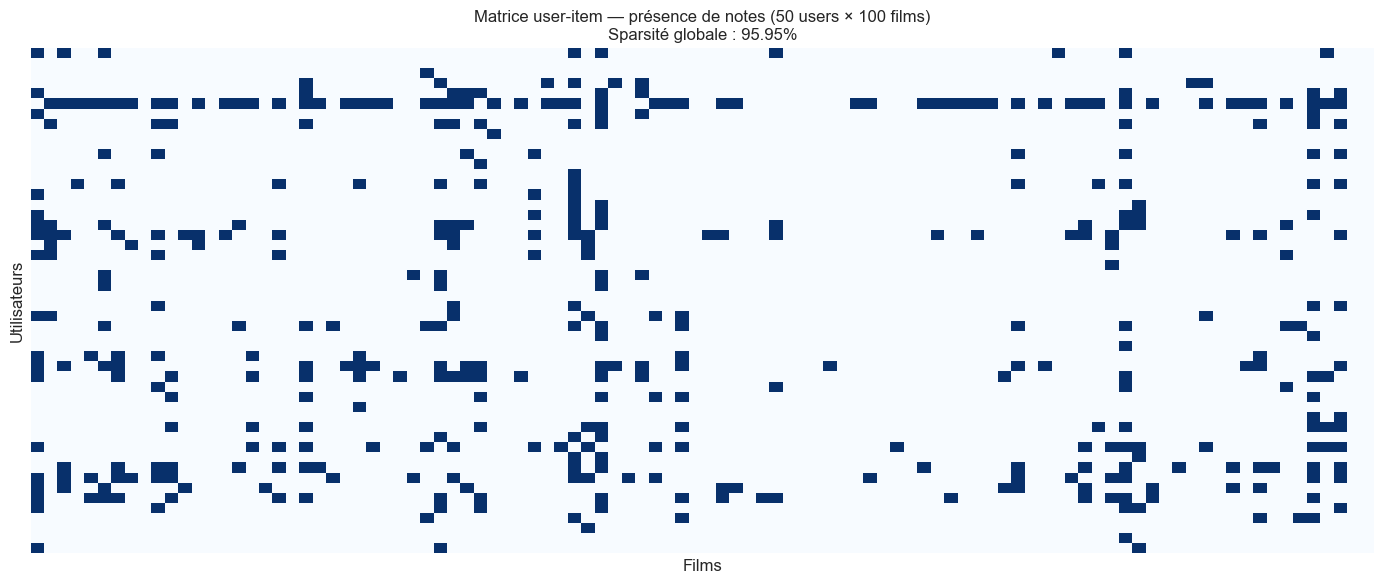

In [9]:
sample = matrix.iloc[:50, :100]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    sample.notna().astype(int), ax=ax,
    cmap="Blues", cbar=False,
    xticklabels=False, yticklabels=False,
)
ax.set_title(f"Matrice user-item — présence de notes (50 users × 100 films)\nSparsité globale : {sparsity:.2%}")
ax.set_xlabel("Films")
ax.set_ylabel("Utilisateurs")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "sparsity_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Analyse des genres

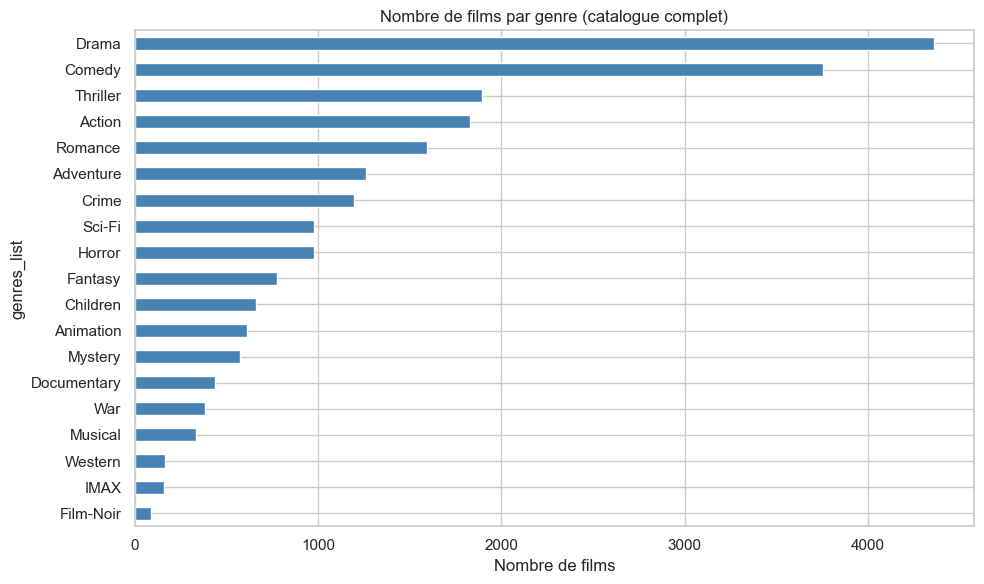

In [10]:
genre_counts = (
    movies["genres_list"].explode()
    .value_counts()
    .drop("(no genres listed)", errors="ignore")
)

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Nombre de films par genre (catalogue complet)")
ax.set_xlabel("Nombre de films")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "genre_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

2026-06-10 09:36:02 | INFO     | Item features : (3650, 8)


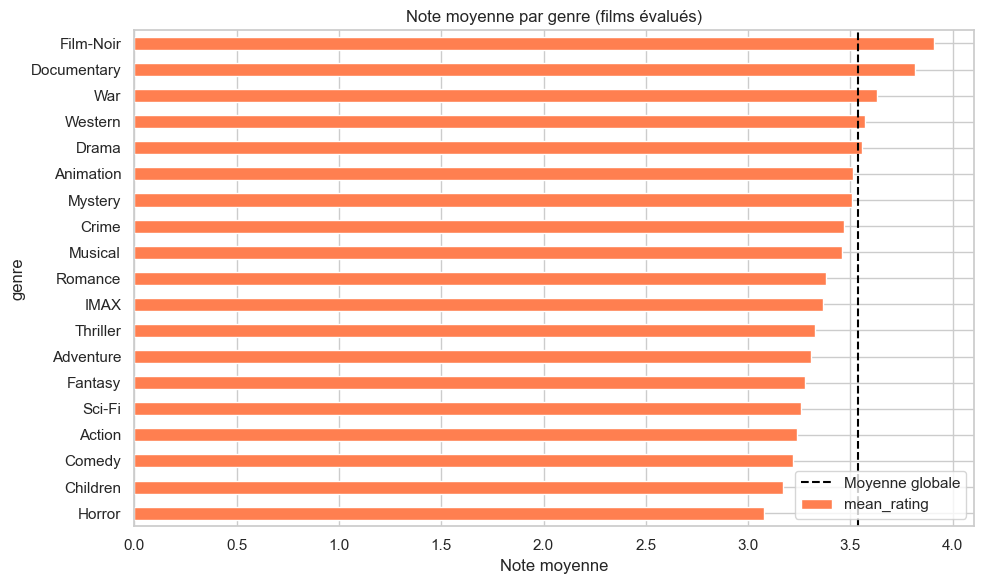

,mean_rating,n_films
genre,,
Film-Noir,3.909,34
Documentary,3.814,57
War,3.631,156
Western,3.573,69
Drama,3.556,1597
Animation,3.513,227
Mystery,3.507,258
Crime,3.467,522
Musical,3.458,145


In [11]:
item_feats = build_item_features(ratings, movies, save=False)

genre_ratings = (
    item_feats[["genres_list", "item_mean_rating", "item_n_ratings"]]
    .explode("genres_list")
    .rename(columns={"genres_list": "genre"})
    .query("genre != '(no genres listed)'")
    .groupby("genre")
    .agg(mean_rating=("item_mean_rating", "mean"), n_films=("item_mean_rating", "count"))
    .sort_values("mean_rating", ascending=False)
    .round(3)
)

fig, ax = plt.subplots(figsize=(10, 6))
genre_ratings["mean_rating"].sort_values().plot(kind="barh", ax=ax, color="coral")
ax.axvline(ratings["rating"].mean(), color="black", linestyle="--", label="Moyenne globale")
ax.set_title("Note moyenne par genre (films évalués)")
ax.set_xlabel("Note moyenne")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "genre_ratings.png", dpi=150, bbox_inches="tight")
plt.show()

display(genre_ratings)

## 8. Features utilisateurs

2026-06-10 09:36:02 | INFO     | User features : (610, 6)


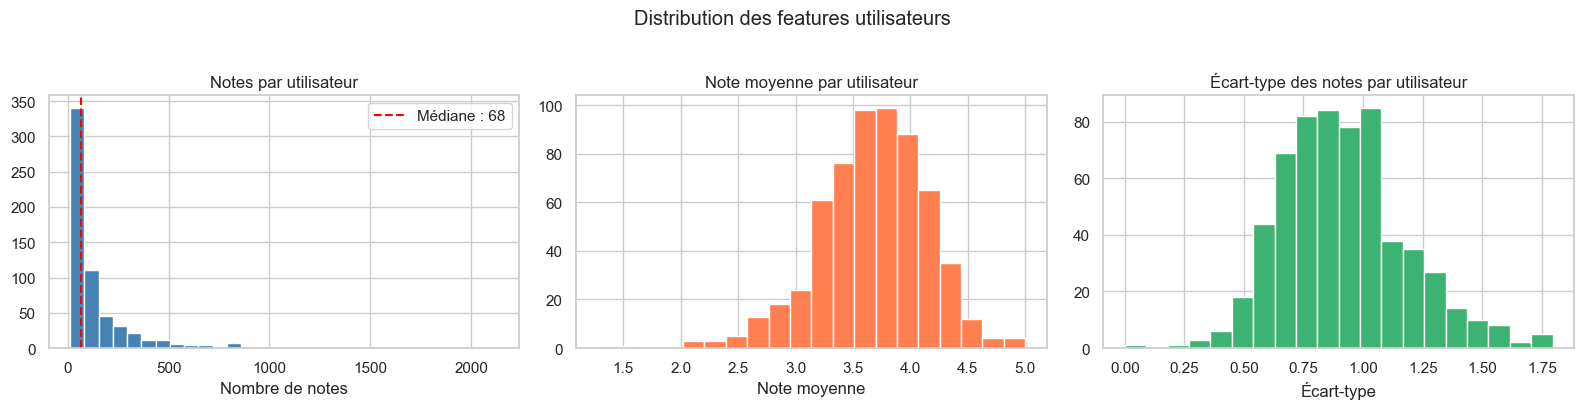

,userid,user_n_ratings,user_mean_rating,user_std_rating,user_min_rating,user_max_rating
count,610.000,610.000,610.000,610.000,610.000,610.000
mean,305.500,147.990,3.668,0.917,1.348,4.955
std,176.236,216.882,0.484,0.262,0.847,0.194
min,1.000,12.000,1.275,0.000,0.500,2.500
25%,153.250,34.000,3.380,0.725,0.500,5.000
50%,305.500,68.000,3.698,0.888,1.000,5.000
75%,457.750,159.000,4.000,1.063,2.000,5.000
max,610.000,2132.000,5.000,1.795,5.000,5.000


In [12]:
user_feats = build_user_features(ratings, save=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(user_feats["user_n_ratings"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Notes par utilisateur")
axes[0].set_xlabel("Nombre de notes")
axes[0].axvline(user_feats["user_n_ratings"].median(), color="red", linestyle="--",
                label=f"Médiane : {user_feats['user_n_ratings'].median():.0f}")
axes[0].legend()

axes[1].hist(user_feats["user_mean_rating"], bins=20, color="coral", edgecolor="white")
axes[1].set_title("Note moyenne par utilisateur")
axes[1].set_xlabel("Note moyenne")

axes[2].hist(user_feats["user_std_rating"].dropna(), bins=20, color="mediumseagreen", edgecolor="white")
axes[2].set_title("Écart-type des notes par utilisateur")
axes[2].set_xlabel("Écart-type")

plt.suptitle("Distribution des features utilisateurs", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "user_features.png", dpi=150, bbox_inches="tight")
plt.show()

display(user_feats.describe().round(3))

## 9. Top films les mieux notés (≥ 50 notes)

In [13]:
top_films = (
    item_feats[item_feats["item_n_ratings"] >= 50]
    .sort_values("item_mean_rating", ascending=False)
    .head(15)[["title_clean", "year", "genres", "item_n_ratings", "item_mean_rating"]]
)
display(top_films)

,title_clean,year,genres,item_n_ratings,item_mean_rating
203,"Shawshank Redemption, The",1994.0,Crime|Drama,317,4.4290
462,"Godfather, The",1972.0,Crime|Drama,192,4.2891
1472,Fight Club,1999.0,Action|Crime|Drama|Thriller,218,4.2729
704,Cool Hand Luke,1967.0,Drama,57,4.2719
424,Dr. Strangelove or: How I Learned to Stop Worr...,1964.0,Comedy|War,97,4.2680
476,Rear Window,1954.0,Mystery|Thriller,84,4.2619
652,"Godfather: Part II, The",1974.0,Crime|Drama,129,4.2597
2874,"Departed, The",2006.0,Crime|Drama|Thriller,107,4.2523
644,Goodfellas,1990.0,Crime|Drama,126,4.2500
483,Casablanca,1942.0,Drama|Romance,100,4.2400


## 10. Analyse temporelle

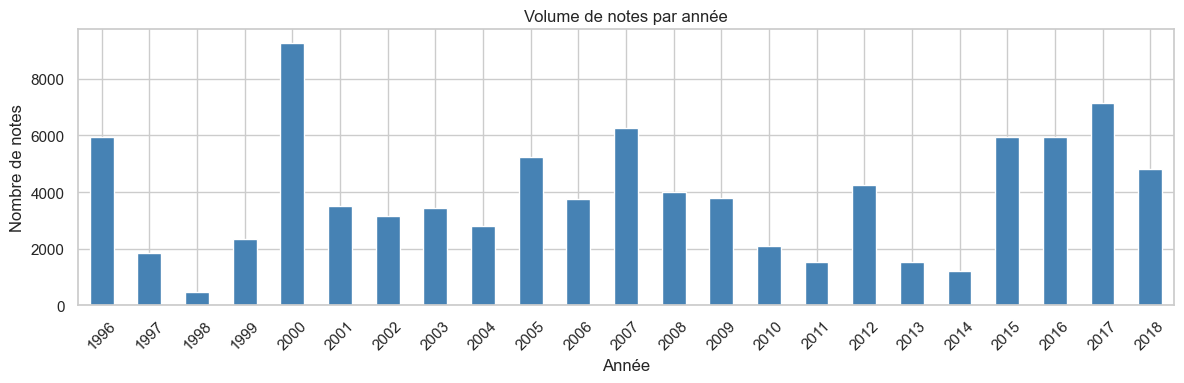

In [14]:
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")
notes_par_an = ratings.groupby(ratings["date"].dt.year).size()

fig, ax = plt.subplots(figsize=(12, 4))
notes_par_an.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Volume de notes par année")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre de notes")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Corrélations features utilisateurs

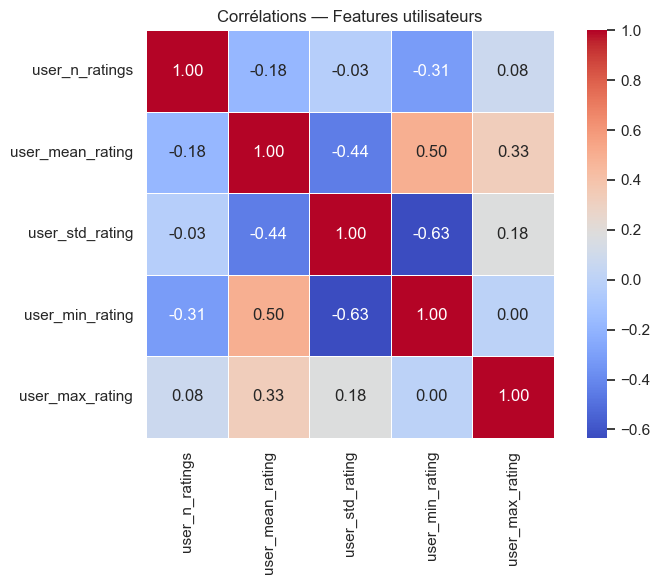

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    user_feats.drop(columns="userid").corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    ax=ax, square=True, linewidths=0.5,
)
ax.set_title("Corrélations — Features utilisateurs")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "reports" / "user_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Log complet MLflow

In [16]:
with mlflow.start_run(run_name="EDA_full_analysis"):
    mlflow.log_metrics({k: v for k, v in summary.items() if isinstance(v, (int, float))})
    mlflow.log_metric("sparsity_pct", round(sparsity * 100, 4))
    mlflow.log_metric("user_avg_n_ratings", round(user_feats["user_n_ratings"].mean(), 3))
    mlflow.log_metric("item_avg_n_ratings", round(item_feats["item_n_ratings"].mean(), 3))
    for img in (PROJECT_DIR / "reports").glob("*.png"):
        mlflow.log_artifact(str(img))
    logger.success("EDA complète loggée dans MLflow")

2026-06-10 09:36:04 | SUCCESS  | EDA complète loggée dans MLflow


## Résumé EDA

| Métrique | Valeur |
|---|---|
| Notes brutes | 100 836 |
| Notes filtrées (≥5) | ~90 274 (89,5%) |
| Utilisateurs actifs | 610 |
| Films évalués | 3 650 |
| Densité matrice | ~4,05% |
| Note moyenne | ~3,54 |
| Genres distincts | 20 |

**Prochaine étape** : modélisation avec `python src/trainer.py` et optimisation Optuna.